# Hafta 12: Makine Öğrenmesi I: Biyolojik Verilerden Özellik Çıkarımı ve Denetimsiz Öğrenme

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. Makine öğrenmesi iş akışını ve denetimli/denetimsiz öğrenme ayrımını kavramak.
2. DNA ve protein dizilerini sayısal **özellik vektörlerine** dönüştürmek (one-hot, k-mer, amino asit bileşimi, fizikokimyasal özellikler).
3. Ölçekleme ve uzaklık ölçülerinin etkisini görmek.
4. PCA'yı elle (özdeğer ayrışımı) ve scikit-learn ile uygulamak.
5. k-ortalamalar ve hiyerarşik kümeleme ile tümör alt tiplerini **etiketsiz** keşfetmeye çalışmak; yığın (batch) etkisini fark etmek.

**Veri:** `tumor_ifade.csv` (200 tümör × 1000 gen, log2 ölçek, sentetik), `tumor_etiketler.csv` (alt tip + merkez), `peptitler.csv`, `protein_ailesi.fasta`

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_tumor(klasor="veri"):
    """tumor_ifade.csv (200 örnek x 1000 gen, log2 ölçek), tumor_etiketler.csv, tumor_marker_genler.csv"""
    import os
    import numpy as np
    import pandas as pd
    os.makedirs(klasor, exist_ok=True)
    rng = np.random.default_rng(12)
    G = 1000
    tipler = {"A": 70, "B": 60, "C": 45, "D": 25}
    genler = [f"g{i:04d}" for i in range(1, G + 1)]
    mu = rng.normal(7, 1.5, G)
    sd = rng.uniform(0.5, 1.1, G)
    # gen modülleri: ortak gizli faktörlerle korelasyon
    faktor_yuk = np.zeros((G, 5))
    for k in range(5):
        idx = rng.choice(G, 80, replace=False)
        faktor_yuk[idx, k] = rng.uniform(0.2, 0.5, 80)
    marker = {}
    kalan = list(rng.permutation(G))
    for t in tipler:
        marker[t] = [kalan.pop() for _ in range(30)]
    ortak_CD = [kalan.pop() for _ in range(20)]            # C ve D alt tiplerinin ortak belirteçleri
    satirlar, etiket, merkez = [], [], []
    for t, n in tipler.items():
        for _ in range(n):
            x = mu + sd * rng.normal(size=G) + faktor_yuk @ rng.normal(size=5)
            idx = marker[t]
            if t in ("A", "B"):                             # belirgin alt tipler
                x[idx[:20]] += rng.uniform(0.7, 1.4, 20)
                x[idx[20:]] -= rng.uniform(0.7, 1.4, 10)
            else:                                           # C ve D birbirine benzer, farkları zayıf
                x[ortak_CD] += rng.uniform(0.7, 1.4, 20)
                x[idx[:20]] += rng.uniform(0.25, 0.6, 20)
                x[idx[20:]] -= rng.uniform(0.25, 0.6, 10)
            m = "Merkez1" if rng.random() < 0.55 else "Merkez2"
            if m == "Merkez2":
                x[:120] += 0.6                             # yığın (batch) etkisi
            satirlar.append(x); etiket.append(t); merkez.append(m)
    X = np.round(np.array(satirlar), 3)
    sira = rng.permutation(len(X))
    ornek = [f"TMR{i:03d}" for i in range(1, len(X) + 1)]
    pd.DataFrame(X[sira], index=pd.Index(ornek, name="ornek"), columns=genler).to_csv(
        os.path.join(klasor, "tumor_ifade.csv"))
    pd.DataFrame({"ornek": ornek, "alt_tip": np.array(etiket)[sira],
                  "merkez": np.array(merkez)[sira]}).to_csv(
        os.path.join(klasor, "tumor_etiketler.csv"), index=False)
    pd.DataFrame([(genler[g], t, "yukari" if i < 20 else "asagi")
                  for t, lst in marker.items() for i, g in enumerate(lst)]
                 + [(genler[g], "C+D", "yukari") for g in ortak_CD],
                 columns=["gen", "alt_tip", "yon"]).to_csv(
        os.path.join(klasor, "tumor_marker_genler.csv"), index=False)


def veri_uret_peptit(klasor="veri"):
    """peptitler.csv: 600 peptit; amp=1 antimikrobiyal peptit (dengesiz: 150 pozitif)"""
    import os, random, csv
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(8)
    aa = "ACDEFGHIKLMNPQRSTVWY"
    arka = [8.3, 1.4, 5.5, 6.8, 3.9, 7.1, 2.3, 5.9, 5.8, 9.7, 2.4, 4.1, 4.7, 3.9, 5.4, 6.6, 5.3, 6.9, 1.1, 2.9]
    amp = list(arka)
    for harf, kat in {"K": 2.6, "R": 2.4, "L": 1.5, "W": 2.5, "I": 1.6, "F": 1.4, "C": 1.8,
                      "D": 0.35, "E": 0.35, "Q": 0.6, "N": 0.6}.items():
        amp[aa.index(harf)] *= kat
    satirlar = []
    for i in range(600):
        pozitif = i < 150
        n = rng.randint(12, 40)
        w = amp if pozitif else arka
        if not pozitif and rng.random() < 0.15:              # zor negatifler: katyonik ama AMP değil
            w = [x * (1.8 if a in "KR" else 1) for a, x in zip(aa, arka)]
        s = "".join(rng.choices(aa, weights=w, k=n))
        satirlar.append((f"pep_{i+1:03d}", s, int(pozitif)))
    rng.shuffle(satirlar)
    with open(os.path.join(klasor, "peptitler.csv"), "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["id", "dizi", "amp"])
        w.writerows(satirlar)


def veri_uret_protein_ailesi(klasor="veri"):
    """protein_ailesi.fasta (hizasız), protein_ailesi_hizali.aln (gerçek MSA, Clustal)."""
    import os, random
    from Bio.Seq import Seq
    from Bio.SeqRecord import SeqRecord
    from Bio.Align import MultipleSeqAlignment
    from Bio import SeqIO, AlignIO
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(2026)
    aa = "ACDEFGHIKLMNPQRSTVWY"
    frek = [8.3, 1.4, 5.5, 6.8, 3.9, 7.1, 2.3, 5.9, 5.8, 9.7, 2.4, 4.1, 4.7, 3.9, 5.4, 6.6, 5.3, 6.9, 1.1, 2.9]
    # Yer değiştirme olasılıkları BLOSUM62'den türetilir: P(b|a) ∝ p_b * 2^(s(a,b)/2)
    from Bio.Align import substitution_matrices
    B62 = substitution_matrices.load("BLOSUM62")
    gecis = {a: [0 if b == a else frek[j] * 2 ** (B62[a][b] / 2) for j, b in enumerate(aa)] for a in aa}
    L = 160
    ata = ["M"] + rng.choices(aa, weights=frek, k=L - 1)
    korunmus = set(rng.sample(range(1, L), 35)) | {0}

    def evrim(dizi, t):
        yeni = list(dizi)
        for i in range(len(yeni)):
            if yeni[i] == "-" or i in korunmus:
                continue
            if rng.random() < t:
                yeni[i] = rng.choices(aa, weights=gecis[yeni[i]])[0]
        if rng.random() < t * 2.5:                      # delesyon olayı
            u = rng.randint(1, 5)
            b = rng.randint(5, L - u - 5)
            if not any(k in korunmus for k in range(b, b + u)):
                for k in range(b, b + u):
                    yeni[k] = "-"
        return yeni

    # ((A1,A2),(A3,(A4,A5))) , ((B1,B2),B3)
    kA = evrim(ata, 0.15); kB = evrim(ata, 0.25)
    kA1 = evrim(kA, 0.08); kA2 = evrim(kA, 0.12)
    diziler = {
        "protA1": evrim(kA1, 0.05), "protA2": evrim(kA1, 0.06),
        "protA3": evrim(kA2, 0.10), "protA4": evrim(evrim(kA2, 0.05), 0.05),
        "protA5": evrim(evrim(kA2, 0.05), 0.07),
        "protB1": evrim(kB, 0.08), "protB2": evrim(kB, 0.10), "protB3": evrim(kB, 0.20),
    }
    hizali = MultipleSeqAlignment([SeqRecord(Seq("".join(v)), id=k) for k, v in diziler.items()])
    AlignIO.write(hizali, os.path.join(klasor, "protein_ailesi_hizali.aln"), "clustal")
    kayitlar = [SeqRecord(Seq("".join(v).replace("-", "")), id=k, description="sentetik protein ailesi uyesi")
                for k, v in diziler.items()]
    ilgisiz = "M" + "".join(rng.choices(aa, weights=frek, k=149))
    kayitlar.append(SeqRecord(Seq(ilgisiz), id="ilgisiz1", description="aileyle akraba olmayan rastgele protein"))
    SeqIO.write(kayitlar, os.path.join(klasor, "protein_ailesi.fasta"), "fasta")


if not os.path.exists('veri/tumor_ifade.csv'):
    veri_uret_tumor()
    veri_uret_peptit()
    veri_uret_protein_ailesi()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'peptitler.csv', 'protein_ailesi.fasta', 'protein_ailesi_hizali.aln', 'tumor_etiketler.csv', 'tumor_ifade.csv', 'tumor_marker_genler.csv']


## 1. Makine öğrenmesi iş akışı
```
Ham biyolojik veri (dizi / ifade / yapı)
   → Özellik çıkarımı (sayısal vektör)  → Ön işleme (ölçekleme, filtreleme)
   → Model (denetimsiz: kümeleme, boyut indirgeme | denetimli: sınıflandırma, regresyon)
   → Değerlendirme  → Yorum ve biyolojik doğrulama
```

| | Denetimsiz öğrenme | Denetimli öğrenme |
|---|---|---|
| Etiket | Yok | Var (sınıf/değer) |
| Amaç | Yapı keşfi | Tahmin |
| Örnek yöntemler | PCA, t-SNE, k-ortalamalar, hiyerarşik kümeleme | Lojistik regresyon, k-NN, karar ağacı, rastgele orman, SVM, sinir ağı |
| Biyoinformatik örneği | Tümör alt tiplerini keşfetmek, hücre tiplerini kümelemek | Promotör tahmini, protein fonksiyonu, hastalık teşhisi |

Veri matrisi gösterimi: $X \in \mathbb{R}^{n\times p}$ — *n* örnek (satır), *p* özellik (sütun). Gen ifadesinde çoğu zaman **p ≫ n** ("boyut laneti").

## 2. Dizilerden özellik çıkarımı

| Yöntem | Boyut | Konum bilgisi | Örnek (`ACGT`) |
|---|---|---|---|
| One-hot | 4 × L | Korunur | A=[1,0,0,0], C=[0,1,0,0], ... |
| k-mer frekansı | $4^k$ | Kaybolur | k=2: AC, CG, GT → her biri 1/3 |
| Amino asit bileşimi | 20 | Kaybolur | Her amino asidin oranı |
| Fizikokimyasal | az sayıda | Kaybolur | Hidrofobiklik, yük, pI, MW... |

### Sayısal örnek — `ACGTAC` dizisinin 2-mer vektörü
5 adet 2-mer: AC, CG, GT, TA, AC → AC: 2/5 = 0.4, CG: 0.2, GT: 0.2, TA: 0.2, diğer 12 dinükleotit: 0.

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, itertools
from collections import Counter

def one_hot(dizi, alfabe="ACGT"):
    M = np.zeros((len(dizi), len(alfabe)))
    for i, b in enumerate(dizi):
        if b in alfabe:
            M[i, alfabe.index(b)] = 1
    return M

def kmer_vektor(dizi, k=2, alfabe="ACGT", normalize=True):
    kelimeler = ["".join(p) for p in itertools.product(alfabe, repeat=k)]
    say = Counter(dizi[i:i + k] for i in range(len(dizi) - k + 1))
    v = np.array([say[w] for w in kelimeler], dtype=float)
    return (v / v.sum() if normalize and v.sum() else v), kelimeler

print("One-hot (ACGTAC):\n", one_hot("ACGTAC").astype(int))
v, kel = kmer_vektor("ACGTAC", 2)
print("\n2-mer vektörü:", {k: round(float(x), 2) for k, x in zip(kel, v) if x > 0})

One-hot (ACGTAC):
 [[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]
 [0 1 0 0]]

2-mer vektörü: {'AC': 0.4, 'CG': 0.2, 'GT': 0.2, 'TA': 0.2}


In [4]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
AA = "ACDEFGHIKLMNPQRSTVWY"

def protein_ozellikleri(dizi):
    pa = ProteinAnalysis(dizi)
    bilesim = {f"f_{a}": dizi.count(a) / len(dizi) for a in AA}
    return {**bilesim, "uzunluk": len(dizi), "pI": pa.isoelectric_point(), "gravy": pa.gravy(),
            "aromatiklik": pa.aromaticity(), "yuk_pH7": pa.charge_at_pH(7.0),
            "heliks_egilimi": pa.secondary_structure_fraction()[0]}

pep = pd.read_csv("veri/peptitler.csv")
Fp = pd.DataFrame([protein_ozellikleri(s) for s in pep.dizi], index=pep.id)
print("Peptit özellik matrisi:", Fp.shape)
Fp.head().round(3)

Peptit özellik matrisi: (600, 26)


,f_A,f_C,f_D,f_E,f_F,f_G,f_H,f_I,f_K,f_L,...,f_T,f_V,f_W,f_Y,uzunluk,pI,gravy,aromatiklik,yuk_pH7,heliks_egilimi
id,,,,,,,,,,,,,,,,,,,,,
pep_024,0.000,0.000,0.000,0.067,0.067,0.000,0.000,0.200,0.133,0.200,...,0.067,0.000,0.000,0.067,15,9.700,0.373,0.133,1.760,0.400
pep_410,0.103,0.000,0.051,0.103,0.026,0.103,0.026,0.051,0.077,0.051,...,0.026,0.103,0.000,0.000,39,5.008,-0.623,0.026,-2.142,0.333
pep_573,0.050,0.000,0.025,0.075,0.100,0.050,0.000,0.050,0.100,0.100,...,0.000,0.075,0.000,0.075,40,8.342,-0.123,0.175,0.798,0.375
pep_458,0.071,0.000,0.107,0.107,0.036,0.036,0.143,0.036,0.000,0.036,...,0.036,0.000,0.071,0.000,28,5.234,-1.307,0.107,-4.179,0.286
pep_065,0.125,0.025,0.025,0.025,0.050,0.025,0.025,0.050,0.075,0.200,...,0.075,0.050,0.100,0.050,40,9.861,0.480,0.200,3.836,0.425


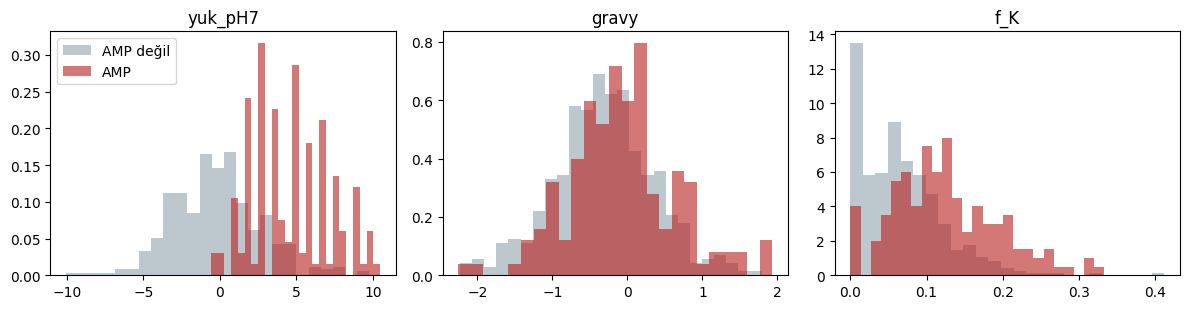

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
for a, oz in zip(ax, ["yuk_pH7", "gravy", "f_K"]):
    for etiket, renk, ad in [(0, "#90a4ae", "AMP değil"), (1, "#b71c1c", "AMP")]:
        a.hist(Fp[oz][pep.set_index("id").amp == etiket], bins=25, alpha=0.6, color=renk, label=ad, density=True)
    a.set_title(oz)
ax[0].legend(); plt.tight_layout(); plt.show()

> Antimikrobiyal peptitler (AMP) belirgin şekilde **pozitif yüklü** (K, R zengini). Tek bir özellik bile ayırt edici olabilir ama
dağılımlar örtüşüyor — birden fazla özelliği birleştiren modellere (13–15. haftalar) ihtiyaç var.

## 3. Ölçekleme ve uzaklık
Özelliklerin birimleri farklıysa (uzunluk ~ 10–40, frekans ~ 0–0.3), büyük ölçekli özellik uzaklığı domine eder.

**Standartlaştırma (z-skoru):** $z = \dfrac{x - \mu}{\sigma}$ &nbsp;&nbsp; **Min-maks:** $x' = \dfrac{x - x_{min}}{x_{max}-x_{min}}$

**Sayısal örnek:** İki peptit: (uzunluk, f_K) = (20, 0.10) ve (30, 0.30). Öklid uzaklığı $\sqrt{10^2 + 0.2^2} \approx 10.002$ → neredeyse tamamen uzunluktan geliyor.
Uzunluğun σ = 8, f_K'nın σ = 0.08 olduğunu varsayarsak ölçeklenmiş farklar 1.25 ve 2.5 → uzaklık $\sqrt{1.25^2+2.5^2} = 2.80$ (artık f_K daha etkili).

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
a, b = np.array([20, 0.10]), np.array([30, 0.30])
print("Ham uzaklık:", np.linalg.norm(a - b).round(3))
print("Ölçekli uzaklık (σ=8, 0.08):", np.linalg.norm((a - b) / np.array([8, 0.08])).round(3))

Fs = StandardScaler().fit_transform(Fp)
print("Ölçekleme sonrası ilk 3 özelliğin ortalaması/std:", Fs[:, :3].mean(0).round(3), Fs[:, :3].std(0).round(3))

Ham uzaklık: 10.002
Ölçekli uzaklık (σ=8, 0.08): 2.795
Ölçekleme sonrası ilk 3 özelliğin ortalaması/std: [-0.  0. -0.] [1. 1. 1.]


## 4. Temel bileşen analizi (PCA)
Amaç: verinin en çok **varyans** gösterdiği dik yönleri bulmak.
1. Veriyi merkezle: $\tilde X = X - \bar X$
2. Kovaryans matrisi: $\Sigma = \dfrac{1}{n-1}\tilde X^T\tilde X$
3. Özdeğer ayrışımı: $\Sigma v_k = \lambda_k v_k$ → $v_k$: bileşen yönleri, $\lambda_k$: açıklanan varyans
4. İzdüşüm: $Z = \tilde X V$

### Sayısal örnek (2 gen, 4 örnek)
| Örnek | gen1 | gen2 |
|---|---|---|
| 1 | 2 | 1 |
| 2 | 3 | 3 |
| 3 | 4 | 3 |
| 4 | 5 | 5 |

Ortalamalar (3.5, 3) → merkezlenmiş: (−1.5,−2), (−0.5,0), (0.5,0), (1.5,2).
$\Sigma = \dfrac{1}{3}\begin{pmatrix}5 & 6\\ 6 & 8\end{pmatrix} = \begin{pmatrix}1.667 & 2\\ 2 & 2.667\end{pmatrix}$

Özdeğerler: $\lambda^2 - 4.333\lambda + 0.444 = 0$ → λ₁ ≈ 4.228, λ₂ ≈ 0.105. PC1 varyansın **%97.6**'sını açıklar;
yönü ≈ (0.615, 0.788): iki gen birlikte artıyor.

In [7]:
X4 = np.array([[2, 1], [3, 3], [4, 3], [5, 5.]])
Xc = X4 - X4.mean(0)
S = Xc.T @ Xc / (len(X4) - 1)
ozdeger, ozvektor = np.linalg.eigh(S)
sira = np.argsort(ozdeger)[::-1]; ozdeger, ozvektor = ozdeger[sira], ozvektor[:, sira]
print("Kovaryans:\n", S.round(3))
print("Özdeğerler:", ozdeger.round(3), "| açıklanan varyans oranı:", (ozdeger / ozdeger.sum()).round(3))
print("PC1 yönü:", ozvektor[:, 0].round(3))
print("PC skorları (elle):\n", (Xc @ ozvektor).round(3))

from sklearn.decomposition import PCA
p = PCA().fit(X4)
print("scikit-learn açıklanan varyans oranı:", p.explained_variance_ratio_.round(3), "(işaret farkı önemsizdir)")

Kovaryans:
 [[1.667 2.   ]
 [2.    2.667]]
Özdeğerler: [4.228 0.105] | açıklanan varyans oranı: [0.976 0.024]
PC1 yönü: [0.615 0.788]
PC skorları (elle):
 [[-2.5   -0.049]
 [-0.308  0.394]
 [ 0.308 -0.394]
 [ 2.5    0.049]]
scikit-learn açıklanan varyans oranı: [0.976 0.024] (işaret farkı önemsizdir)


(200, 1000)
{'A': 70, 'B': 60, 'C': 45, 'D': 25} {'Merkez1': 112, 'Merkez2': 88}


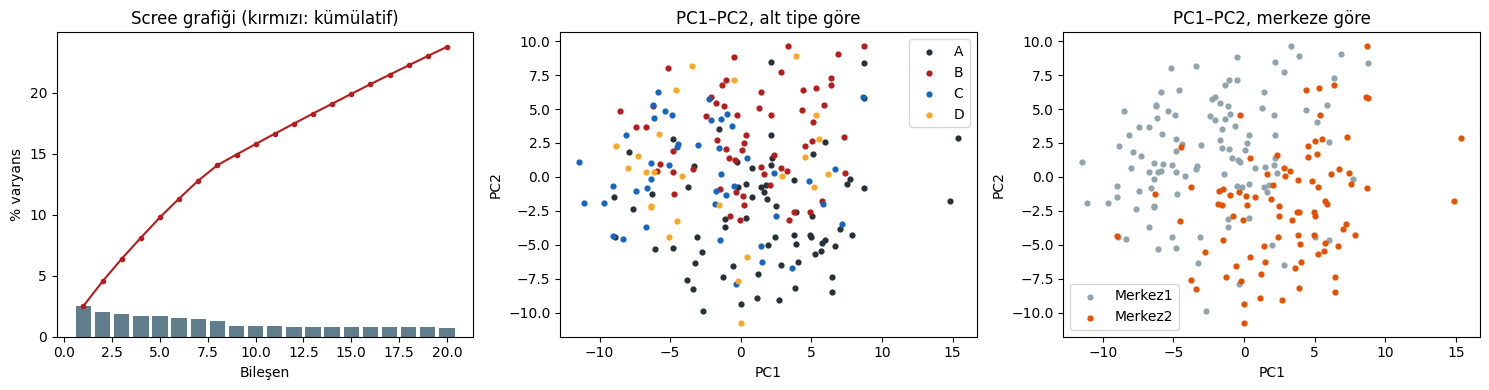

In [8]:
X = pd.read_csv("veri/tumor_ifade.csv", index_col=0)
etiket = pd.read_csv("veri/tumor_etiketler.csv").set_index("ornek").loc[X.index]
print(X.shape); print(etiket.alt_tip.value_counts().to_dict(), etiket.merkez.value_counts().to_dict())

Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=20).fit(Xs)
Z = pca.transform(Xs)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(range(1, 21), 100 * pca.explained_variance_ratio_, color="#607d8b")
ax[0].plot(range(1, 21), 100 * np.cumsum(pca.explained_variance_ratio_), "o-", color="#b71c1c", ms=3)
ax[0].set_xlabel("Bileşen"); ax[0].set_ylabel("% varyans"); ax[0].set_title("Scree grafiği (kırmızı: kümülatif)")
renkler = {"A": "#263238", "B": "#b71c1c", "C": "#1565c0", "D": "#f9a825"}
for t, r in renkler.items():
    m = etiket.alt_tip.values == t
    ax[1].scatter(Z[m, 0], Z[m, 1], s=12, color=r, label=t)
ax[1].set_title("PC1–PC2, alt tipe göre"); ax[1].legend()
for mz, r in [("Merkez1", "#90a4ae"), ("Merkez2", "#e65100")]:
    m = etiket.merkez.values == mz
    ax[2].scatter(Z[m, 0], Z[m, 1], s=12, color=r, label=mz)
ax[2].set_title("PC1–PC2, merkeze göre"); ax[2].legend()
for a in ax[1:]:
    a.set_xlabel("PC1"); a.set_ylabel("PC2")
plt.tight_layout(); plt.show()

In [9]:
# Hangi bileşen merkez (yığın) etkisini taşıyor?
from scipy import stats
for k in range(6):
    r_merkez = abs(np.corrcoef(Z[:, k], (etiket.merkez == "Merkez2").astype(int))[0, 1])
    f = stats.f_oneway(*[Z[etiket.alt_tip.values == t, k] for t in "ABCD"]).statistic
    print(f"PC{k+1}: merkez ile |r| = {r_merkez:.2f} | alt tip ANOVA F = {f:7.1f}")

PC1: merkez ile |r| = 0.52 | alt tip ANOVA F =     9.4
PC2: merkez ile |r| = 0.41 | alt tip ANOVA F =    22.6
PC3: merkez ile |r| = 0.30 | alt tip ANOVA F =    13.5
PC4: merkez ile |r| = 0.47 | alt tip ANOVA F =     8.1
PC5: merkez ile |r| = 0.16 | alt tip ANOVA F =    36.6
PC6: merkez ile |r| = 0.37 | alt tip ANOVA F =    57.9


> **Yığın (batch) etkisi:** Örneklerin farklı merkezlerde/günlerde işlenmesinden kaynaklanan teknik varyasyondur. Bir bileşenin
biyolojiden çok **merkezle** ilişkili olması tehlike işaretidir. Gerçek çalışmalarda ComBat gibi yöntemlerle düzeltilir veya
modelde değişken olarak kullanılır.

## 5. k-ortalamalar (k-means) kümeleme
1. *k* küme merkezini rastgele seç. 2. Her noktayı en yakın merkeze ata. 3. Merkezleri küme ortalamasına taşı. 4. Değişim yoksa dur.
Amaç fonksiyonu (küme içi kareler toplamı): $W = \sum_{k}\sum_{x\in C_k}\lVert x-\mu_k\rVert^2$

### Sayısal örnek (1 boyut): noktalar 1, 2, 3, 8, 9, 10; k = 2, başlangıç merkezleri 1 ve 2
| Adım | Atama | Yeni merkezler | W |
|---|---|---|---|
| 1 | {1} , {2,3,8,9,10} | 1 , 6.4 | 0 + 53.2 = 53.2 |
| 2 | {1,2,3} , {8,9,10} (6.4'e 3 uzaklığı 3.4 > 2) | 2 , 9 | 2 + 2 = 4 |
| 3 | değişmez | 2 , 9 | 4 → yakınsadı |

In [10]:
def kmeans_elle(x, merkez, adim=10):
    x = np.asarray(x, float); merkez = np.asarray(merkez, float)
    for t in range(adim):
        atama = np.argmin(np.abs(x[:, None] - merkez[None, :]), axis=1)
        yeni = np.array([x[atama == k].mean() for k in range(len(merkez))])
        W = sum(((x[atama == k] - yeni[k]) ** 2).sum() for k in range(len(merkez)))
        print(f"adım {t+1}: kümeler={[x[atama == k].astype(int).tolist() for k in range(len(merkez))]} merkezler={yeni.round(2)} W={W:.2f}")
        if np.allclose(yeni, merkez):
            break
        merkez = yeni
kmeans_elle([1, 2, 3, 8, 9, 10], [1, 2])

adım 1: kümeler=[[1], [2, 3, 8, 9, 10]] merkezler=[1.  6.4] W=53.20
adım 2: kümeler=[[1, 2, 3], [8, 9, 10]] merkezler=[2. 9.] W=4.00
adım 3: kümeler=[[1, 2, 3], [8, 9, 10]] merkezler=[2. 9.] W=4.00


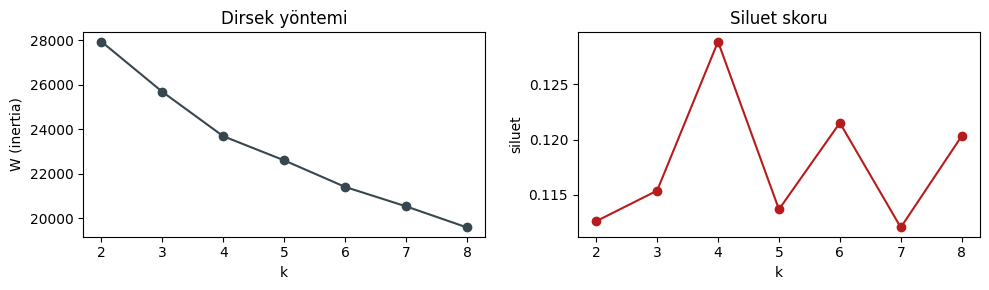

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

Zk = Z[:, :10]            # ilk 10 PC üzerinde kümeleme (gürültüyü azaltır)
ks = range(2, 9)
W, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Zk)
    W.append(km.inertia_); sil.append(silhouette_score(Zk, km.labels_))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(ks, W, "o-", color="#37474f"); ax[0].set_xlabel("k"); ax[0].set_ylabel("W (inertia)"); ax[0].set_title("Dirsek yöntemi")
ax[1].plot(ks, sil, "o-", color="#b71c1c"); ax[1].set_xlabel("k"); ax[1].set_ylabel("siluet"); ax[1].set_title("Siluet skoru")
plt.tight_layout(); plt.show()

In [12]:
km = KMeans(n_clusters=4, n_init=20, random_state=0).fit(Zk)
print("Düzeltilmiş Rand indeksi (ARI) - alt tip ile:", round(adjusted_rand_score(etiket.alt_tip, km.labels_), 3))
print("ARI - merkez ile:", round(adjusted_rand_score(etiket.merkez, km.labels_), 3))
pd.crosstab(etiket.alt_tip, km.labels_, rownames=["gerçek alt tip"], colnames=["k-means kümesi"])

Düzeltilmiş Rand indeksi (ARI) - alt tip ile: 0.705
ARI - merkez ile: 0.032


k-means kümesi,0,1,2,3
gerçek alt tip,,,,
A,9,0,0,61
B,5,55,0,0
C,7,0,37,1
D,8,0,16,1


**ARI:** 1 = mükemmel uyum, 0 ≈ rastgele (küme numaraları keyfidir; ARI bu permütasyondan etkilenmez).
Denetimsiz yöntem etiketleri hiç görmeden belirgin alt tipler olan **A ve B**'yi büyük ölçüde ayırdı; ortak belirteçleri olan ve
birbirine çok benzeyen **C ile D**'yi ise tek bir kümede topladı. Dördüncü küme farklı alt tiplerden örneklerin karışımı.
Ayrıca sonuç; ölçeklemeye, kullanılan bileşen sayısına ve yönteme duyarlıdır: aşağıda *single* ve *average* bağlantılı hiyerarşik
kümeleme başarısız oluyor, 4. alıştırmada ise "en değişken genler" seçimi sonucu kötüleştiriyor. C–D ayrımını 14. haftada
**denetimli** öğrenmeyle ne kadar iyi yapabildiğimizi göreceğiz. Denetimsiz sonuçlar her zaman bağımsız bilgiyle doğrulanmalıdır.

## 6. Hiyerarşik kümeleme
Aşağıdan yukarı (aglomeratif): her örnek ayrı küme → en yakın iki kümeyi birleştir → tek küme kalana dek tekrarla (9. haftadaki UPGMA ile aynı fikir!).

| Bağlantı (linkage) | Kümeler arası uzaklık |
|---|---|
| single | En yakın iki üye |
| complete | En uzak iki üye |
| average (UPGMA) | Tüm çiftlerin ortalaması |
| ward | Birleşmenin W'yi en az artırdığı çift |

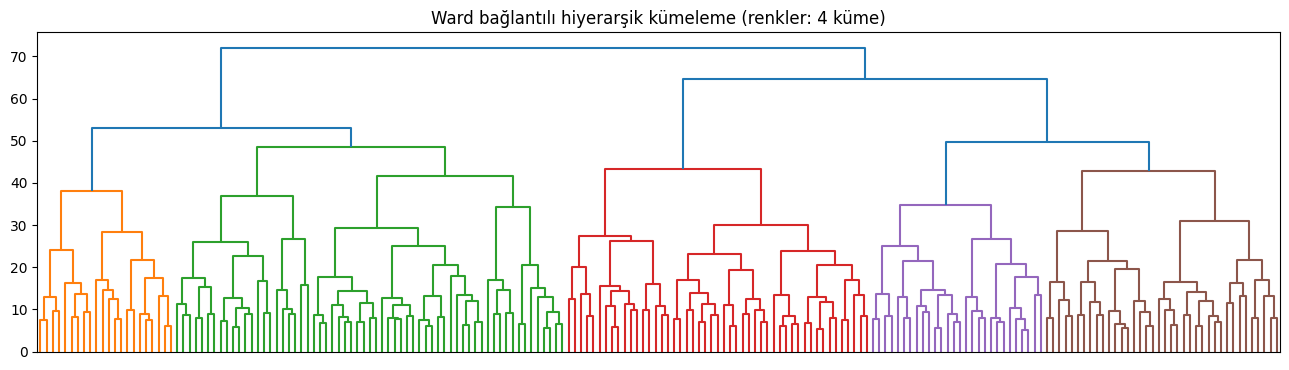

single    ARI = 0.000
complete  ARI = 0.100
average   ARI = -0.006
ward      ARI = 0.572


In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
L = linkage(Zk, method="ward")
fig, ax = plt.subplots(figsize=(13, 3.8))
dendrogram(L, ax=ax, no_labels=True, color_threshold=L[-4, 2])
ax.set_title("Ward bağlantılı hiyerarşik kümeleme (renkler: 4 küme)"); plt.tight_layout(); plt.show()
h4 = fcluster(L, 4, criterion="maxclust")
for yontem in ["single", "complete", "average", "ward"]:
    et = fcluster(linkage(Zk, method=yontem), 4, criterion="maxclust")
    print(f"{yontem:9s} ARI = {adjusted_rand_score(etiket.alt_tip, et):.3f}")

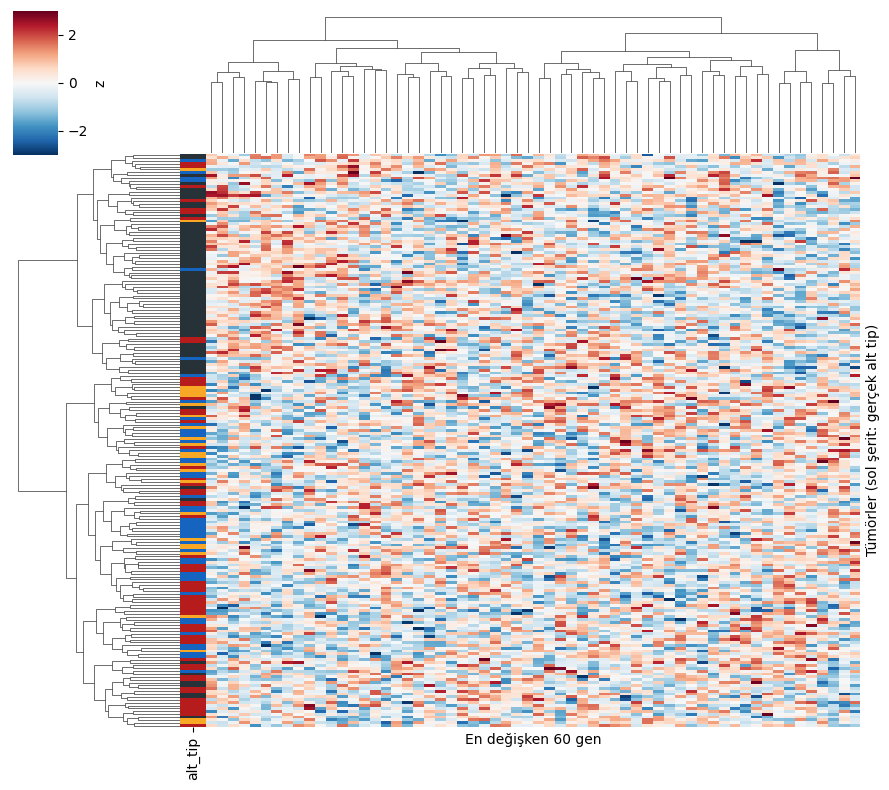

In [14]:
import seaborn as sns, warnings
warnings.filterwarnings("ignore", category=UserWarning)
degisken = X.var().sort_values(ascending=False).index[:60]
renk_satir = etiket.alt_tip.map(renkler)
g = sns.clustermap(X[degisken].sub(X[degisken].mean()).div(X[degisken].std()), cmap="RdBu_r", center=0, vmin=-3, vmax=3,
                   row_colors=renk_satir, method="ward", figsize=(9, 8), xticklabels=False, yticklabels=False,
                   cbar_kws={"label": "z"})
g.ax_heatmap.set_xlabel("En değişken 60 gen"); g.ax_heatmap.set_ylabel("Tümörler (sol şerit: gerçek alt tip)"); plt.show()

## 7. Doğrusal olmayan boyut indirgeme: t-SNE (kısa)
t-SNE yakın komşulukları korur; görselleştirme için güçlüdür ama **uzaklıklar ve küme boyutları yorumlanmamalıdır**
ve sonuç `perplexity` parametresine duyarlıdır.

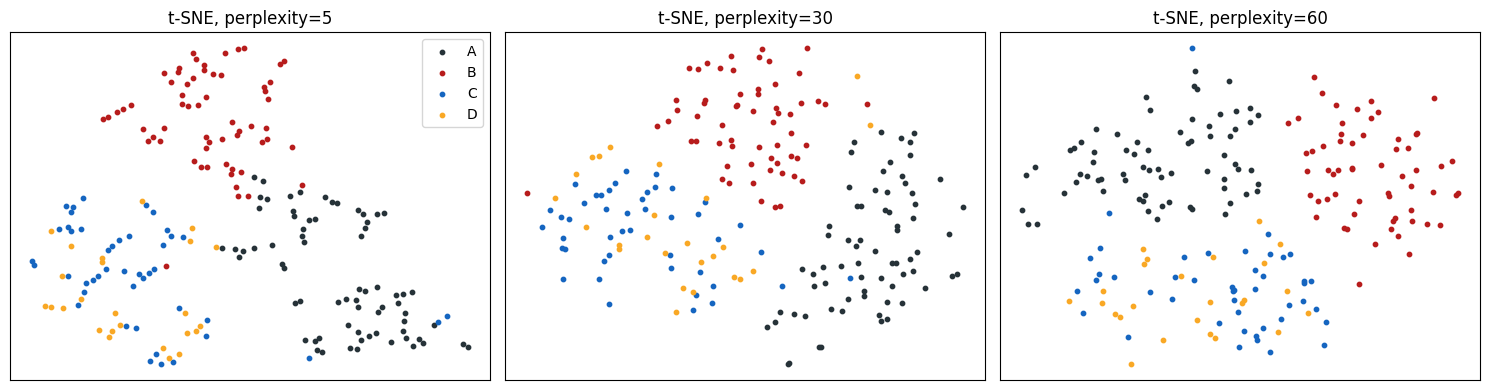

In [15]:
from sklearn.manifold import TSNE
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, perp in zip(ax, [5, 30, 60]):
    T = TSNE(n_components=2, perplexity=perp, random_state=0, init="pca").fit_transform(Zk)
    for t, r in renkler.items():
        m = etiket.alt_tip.values == t
        a.scatter(T[m, 0], T[m, 1], s=10, color=r, label=t)
    a.set_title(f"t-SNE, perplexity={perp}"); a.set_xticks([]); a.set_yticks([])
ax[0].legend(); plt.tight_layout(); plt.show()

## 8. Dizileri k-mer profiliyle kümeleme
Hizalama yapmadan (alignment-free) protein ailesinin alt ailelerini bulabilir miyiz?

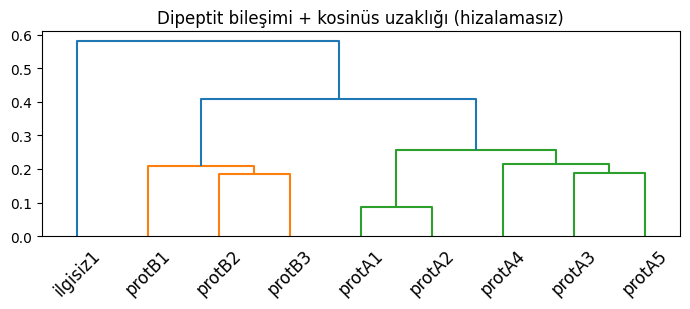

In [16]:
from Bio import SeqIO
kayitlar = list(SeqIO.parse("veri/protein_ailesi.fasta", "fasta"))
V = np.array([kmer_vektor(str(r.seq), k=2, alfabe=AA)[0] for r in kayitlar])     # 400 boyutlu dipeptit bileşimi
L2 = linkage(V, method="average", metric="cosine")
fig, ax = plt.subplots(figsize=(7, 3.2))
dendrogram(L2, labels=[r.id for r in kayitlar], ax=ax, leaf_rotation=45)
ax.set_title("Dipeptit bileşimi + kosinüs uzaklığı (hizalamasız)"); plt.tight_layout(); plt.show()

## 9. Alıştırmalar
1. `GATTACA` dizisinin 3-mer sayım vektöründeki sıfır olmayan elemanları elle yazın; kodla doğrulayın.
2. Noktalar (1,1), (1,2), (4,4), (5,4), (5,5) için başlangıç merkezleri (1,1) ve (5,5) ile k-ortalamaları elle 2 adım uygulayın.
3. Tümör verisinde ölçekleme **yapmadan** PCA uygulayın. PC1–PC2 grafiği ve açıklanan varyans nasıl değişti? Neden?
4. k-means'i yalnızca **en değişken 100 gen** üzerinde çalıştırın. ARI arttı mı?
5. Merkez etkisini basitçe düzeltin: her merkezin gen ortalamasını çıkarın (merkez bazında merkezleme). PCA'yı ve k-means ARI'sini tekrar hesaplayın.

---
## Çözümler

In [17]:
# 1
v, kel = kmer_vektor("GATTACA", 3, normalize=False)
print("1)", {k: int(x) for k, x in zip(kel, v) if x})
# 2
P = np.array([[1, 1], [1, 2], [4, 4], [5, 4], [5, 5.]]); mrk = np.array([[1, 1], [5, 5.]])
for t in range(2):
    at = np.argmin(((P[:, None] - mrk[None]) ** 2).sum(-1), axis=1)
    mrk = np.array([P[at == k].mean(0) for k in range(2)])
    print(f"2) adım {t+1}: atama={at}, merkezler={mrk.round(2).tolist()}")
# 3
p_ham = PCA(2).fit(X.values)
print("3) ölçeksiz açıklanan varyans:", p_ham.explained_variance_ratio_.round(3), "| ölçekli:", pca.explained_variance_ratio_[:2].round(3))
# 4
top = X.var().sort_values(ascending=False).index[:100]
Z100 = PCA(10).fit_transform(StandardScaler().fit_transform(X[top]))
print("4) en değişken 100 gen ARI:", round(adjusted_rand_score(etiket.alt_tip, KMeans(4, n_init=20, random_state=0).fit_predict(Z100)), 3))
# 5
Xd = X.copy()
for mz in etiket.merkez.unique():
    m = (etiket.merkez == mz).values
    Xd.loc[m] = X.loc[m] - X.loc[m].mean()
Zd = PCA(10).fit_transform(StandardScaler().fit_transform(Xd))
print("5) merkez düzeltmeli ARI:", round(adjusted_rand_score(etiket.alt_tip, KMeans(4, n_init=20, random_state=0).fit_predict(Zd)), 3),
      "| merkez ile PC1 korelasyonu:", round(abs(np.corrcoef(Zd[:, 0], (etiket.merkez == "Merkez2").astype(int))[0, 1]), 3))

1) {'ACA': 1, 'ATT': 1, 'GAT': 1, 'TAC': 1, 'TTA': 1}
2) adım 1: atama=[0 0 1 1 1], merkezler=[[1.0, 1.5], [4.67, 4.33]]
2) adım 2: atama=[0 0 1 1 1], merkezler=[[1.0, 1.5], [4.67, 4.33]]
3) ölçeksiz açıklanan varyans: [0.027 0.022] | ölçekli: [0.025 0.02 ]


4) en değişken 100 gen ARI: 0.475


5) merkez düzeltmeli ARI: 0.65 | merkez ile PC1 korelasyonu: 0.0
